In [31]:
%pip install -U microlens_submit
%pip install -U RTModel==3.3
%pip install -U jacscanomaly
%pip install -U microjax
%pip install pyAethra

/opt/conda/envs/rges-pit-dc/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
# system imports
import os
import time
import sys
from pathlib import Path

# data access imports
from huggingface_hub import hf_hub_download
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# display imports
from IPython.display import HTML

# multiprocessing imports
import multiprocessing as mp
from multiprocessing.pool import ThreadPool

# data challenge imports
import microlens_submit
#import MulensModel
import emcee
#from pyLIMA.pyLIMASS import SourceLensProbabilities
import RTModel

# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

# detection packages
from pyAethra import load_config, load_and_run
from jacscanomaly import CandidateCriteria, Finder, FinderConfig


In [35]:
TIER = "Experienced"
REPO_ID = f"RGES-PIT/{TIER}"

FILENAME = f"RMDC26_{TIER}_Tier_test.parquet"  # "_test" tells hugging face this is not a machine learning training set.
local_data_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset")
lc_data_all = pd.read_parquet(local_data_path)
print(local_data_path)
print(lc_data_all)
print(lc_data_all.columns)
print(lc_data_all['name'])

/home/mldc-ipacpeople-admin/.cache/huggingface/hub/datasets--RGES-PIT--Experienced/snapshots/ec43063dcf6656d9099cfd98904fa0ed3a5dee70/RMDC26_Experienced_Tier_test.parquet
                    name     l_deg     b_deg      ra_deg    dec_deg  \
0          RMDC26_002067 -0.458321 -1.731208  267.838726 -30.221671   
1          RMDC26_002067 -0.458321 -1.731208  267.838726 -30.221671   
2          RMDC26_002067 -0.458321 -1.731208  267.838726 -30.221671   
3          RMDC26_002067 -0.458321 -1.731208  267.838726 -30.221671   
4          RMDC26_002067 -0.458321 -1.731208  267.838726 -30.221671   
...                  ...       ...       ...         ...        ...   
102885547  RMDC26_000511  0.807802 -1.012752  267.871272 -28.766507   
102885548  RMDC26_000511  0.807802 -1.012752  267.871272 -28.766507   
102885549  RMDC26_000511  0.807802 -1.012752  267.871272 -28.766507   
102885550  RMDC26_000511  0.807802 -1.012752  267.871272 -28.766507   
102885551  RMDC26_000511  0.807802 -1.012752  26

Events in this tier run from 189 to 2288

Normally, we'd take a bunch of light curves and do event detection straight-up. But the data challenge light curves all have the same time stamps, so the best we can do is to iterate one light curve at a time and do event detection --> anomaly detection --> event modeling per "light curve" (but really per event). So, this isn't super representative of our ability to do event detection (or anomaly detection?). 

Especially for RTModel to work, we need to rearrange the file structure, as follows

#### Rearrange file structure

In [5]:
lc_data_all['bjd-2450000'] = lc_data_all['bjd'] - 2450000

In [7]:
lc_data_all

,name,l_deg,b_deg,ra_deg,dec_deg,bjd,filt,flux_uJy,flux_err_uJy,extinction,saturation_flag,measured_ra_deg,measured_dec_deg,measured_ra_err_deg,measured_dec_err_deg,obs_x,obs_y,obs_z,bjd-2450000
0,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461448e+06,F087,10.893037,0.305048,1.946512,0,267.838741,-30.221657,4.257373e-07,3.678730e-07,-0.787729,0.613209,0.005062,11447.917416
1,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461448e+06,F087,11.351664,0.305048,1.946512,0,267.838743,-30.221657,4.184294e-07,3.615584e-07,-0.790864,0.609200,0.005066,11448.204097
2,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461448e+06,F087,11.214074,0.305048,1.946512,0,267.838743,-30.221657,4.205409e-07,3.633829e-07,-0.793979,0.605175,0.005070,11448.490779
3,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461449e+06,F087,11.725116,0.305048,1.946512,0,267.838742,-30.221657,4.130198e-07,3.568840e-07,-0.800147,0.597079,0.005074,11449.064141
4,RMDC26_002067,-0.458321,-1.731208,267.838726,-30.221671,2.461449e+06,F087,11.347292,0.305048,1.946512,0,267.838742,-30.221658,4.184955e-07,3.616154e-07,-0.803201,0.593009,0.005076,11449.350823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102885547,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462592e+06,F213,105.943582,0.973274,0.550793,0,267.871276,-28.766506,3.808801e-07,3.338750e-07,-0.992297,-0.177175,-0.004360,12591.550978
102885548,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462597e+06,F213,105.074842,0.973274,0.550793,0,267.871276,-28.766507,3.808801e-07,3.338750e-07,-0.974904,-0.261480,-0.004752,12596.550978
102885549,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462602e+06,F213,103.194557,0.973274,0.550793,0,267.871276,-28.766507,3.808801e-07,3.338750e-07,-0.950344,-0.343808,-0.004996,12601.550978
102885550,RMDC26_000511,0.807802,-1.012752,267.871272,-28.766507,2.462607e+06,F213,104.269573,0.973274,0.550793,0,267.871276,-28.766507,3.808801e-07,3.338750e-07,-0.918830,-0.423583,-0.005084,12606.550978


/tmp/ipykernel_606/489637128.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data_filt['mag'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_uJy'])
/tmp/ipykernel_606/489637128.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data_filt['mag_err'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_err_uJy'])


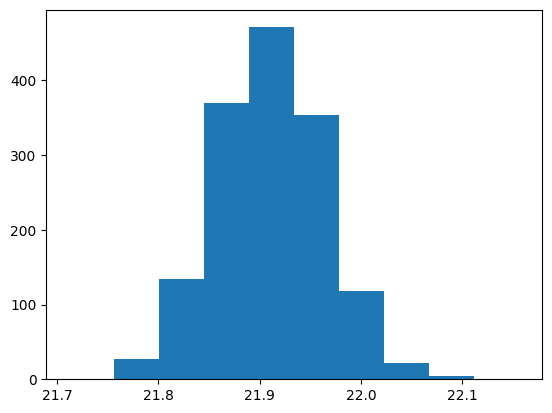

In [17]:
# lc_data_filt['mag'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_uJy'])
# lc_data_filt['mag_err'] = 23.9 - 2.5 * np.log10(lc_data_filt['flux_err_uJy'])
# plt.hist(lc_data_filt['mag'])
# plt.show()

In [21]:
event_data_me = 'event_data_chris/'

In [30]:
root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
filters = ['F087', 'F146', 'F213']
aethra_labels = []
for EVENT_ID in sorted(lc_data_all["name"].unique()):
    print("Working on: ", EVENT_ID)
    
    # pick out event/light curve
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
    actual_id = EVENT_ID.split("_", 1)[1]
    
    # create event directory in the format RTModel wants
    new_event_dir = root_dir + '/' + event_data_me + 'event_' + actual_id
    try:
        os.mkdir(new_event_dir)
    except Exception as e:
        pass
    try:
        os.mkdir(new_event_dir + '/Data/')
    except Exception as e:
        pass

    # each filter should be converted to a .dat file with the following header: # Mag err HJD-2450000
    # furthermore, RTModel is particular about filename structures: .dat files should end with the correct satelllite suffix
    # name schematics follow the schematic from Stela Ishitani Silva's post on WG3 Confluence page
    # https://rgespit.atlassian.net/wiki/spaces/RPTH/pages/154828801/RTModel+v2.4+Runs+for+the+2371+Representative+Sample+Lightcurves
    for filt in filters:
        lc_data_filt = lc_data.loc[lc_data['filt']==filt]#[time_mask]
        lc_data_dat = pd.DataFrame({'Flux': lc_data_filt['flux_uJy'], 'err': lc_data_filt['flux_err_uJy'], 'HJD-2450000': lc_data_filt['bjd-2450000']})
        if filt=='F087':
            dat_filepath = new_event_dir + '/Data/RomanZ087sat2.dat'
        elif filt=='F146':
            dat_filepath = new_event_dir + '/Data/RomanW146sat1.dat'
        elif filt=='F213':
            dat_filepath = new_event_dir + '/Data/RomanK213sat3.dat'
        with open(dat_filepath, "w", encoding="utf-8") as f:
            f.write("# Mag err HJD-2450000\n")
            lc_data_dat.to_csv(f, sep=' ', header=None, index=False)

    # add coordinates in Data/ dir too     
    coords = SkyCoord(ra=lc_data_filt['ra_deg'].values[0]*u.degree, dec=lc_data_filt['dec_deg'].values[0]*u.degree, frame='icrs')
    ra_hms = coords.ra.to_string(unit=u.hourangle, sep=':', pad=True)
    dec_dms = coords.dec.to_string(sep=':', pad=True)
    coord_filepath = new_event_dir + '/Data/event.coordinates'
    with open(coord_filepath, "w", encoding="utf-8") as cf:
        cf.write(f"{ra_hms} {dec_dms}")

    # add limb darkening file in Data/
    limb_dark_filepath = new_event_dir + '/Data/LimbDarkening.txt'
    with open(limb_dark_filepath, "w", encoding="utf-8") as ld:
        ld.write("0.33 \n0.4532 \n0.251")

    ### event detection
    ### now called Aethra: https://github.com/rges-pit/pyAethra
    aethra_config = load_config(root_dir+"/config/aethra_config.yaml") # courtesy of Katie Vandorou
    # this tier uses flux instead of mag, so change just this part of the config
    aethra_config = {
        "time_col": "bjd",
        "mag_col":  "flux_uJy",
        "err_col":  "flux_err_uJy",
        "group_col": "name",   # column identifying each object in the table
    }
    
    results_df = load_and_run(lc_data, aethra_config)
    label = results_df['label'].iloc[0]
    print("label: ", label)
    aethra_labels.append(label)

    if (label!='microlensing') and (label!='ffp'):
        continue

    print(results_df)
    t0_fit = results_df['t0_fit'].iloc[0]
    u0_fit = results_df['u0_fit'].iloc[0]
    tE_fit = results_df['tE_fit'].iloc[0]
    print("t0: ", t0_fit)
    print("u0: ", u0_fit)
    print("tE: ", tE_fit)
    asdfasdfdsf

    ### anomaly detection
    #lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000
    # masks: jacscanomaly only takes the F146 filter
    time_mask = (lc_data["bjd-2450000"] <= t0_fit + tE_fit * 2) & (lc_data["bjd-2450000"] >= t0_fit - tE_fit * 2)
    filter_mask = lc_data["filt"] == 'F146'
    lc_data_filter_mask = lc_data[filter_mask]
    lc_data_mask = lc_data[time_mask & filter_mask]
    #print("length of masked data: ", len(lc_data_mask), " out of: ", len(lc_data))
    
    # load data (time, flux, flux_err)
    #lc_data_season = lc_data.loc[lc_data['
    time = np.array(lc_data_filter_mask["bjd-2450000"])#[time_mask & filter_mask])
    flux = np.array(lc_data_filter_mask["flux_uJy"])#[time_mask & filter_mask])
    fluxerr = np.array(lc_data_filter_mask["flux_err_uJy"])#[time_mask & filter_mask])
    
    # run anomaly finder
    criteria = CandidateCriteria(
        min_dchi2=60.0,
        min_n_eff=2.0,
        #min_n_contrib=2,
        #max_peak_frac=0.8,
    )
    jacscanomaly_config = FinderConfig(
        fitter_kind="pspl",
        candidate_criteria=criteria, # candidate_criteria=CandidateCriteria(min_n_eff=2.0)
        gap=100.0
    )
    finder = Finder(jacscanomaly_config)

    # initial guess is from aethra
    p0 = np.array([t0_fit, tE_fit, u0_fit])  # t0, tE, u0
    result = finder.run(time, flux, fluxerr, p0, data_kind="flux")
    result.print_summary()
    result_summary = result.summary_table()
    print(result_summary)
    
    ### do a couple checks for no or weak anomaly found 
    if result_summary['has_best'].values[0]==False:
        plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['flux_uJy'], lc_data_filter_mask['flux_err_uJy'], )
        plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
        #plt.gca().yaxis.set_inverted(True)
        plt.xlim([t0_fit - 5*tE_fit, t0_fit + 5*tE_fit])
        #plt.xlim([11459-20,11459+120])
        #plt.xlim([11630, 11700])
        plt.ylabel(r'flux [$\micro$Jy]')
        plt.xlabel('BJD-2450000')
        plt.title(f"no anomaly: {EVENT_ID}")
        plt.legend()
        plt.show()
        continue
    else:
        pass
    
    t0_fit_best = result_summary['best_t0'].values[0]
    print("t0_fit_best: ", t0_fit_best)
    best_score = result_summary['best_score'].values[0]
    print("best score: ", best_score)
    if best_score < 10:
        print("does not pass score threshold of 10")
        continue

    # # plot to inspect PSPL fit
    # finder.plot_result()
    # finder.plot_anomaly_window()
    # plt.show()

    plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['flux_uJy'], lc_data_filter_mask['flux_err_uJy'], )
    plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
    plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
    #plt.gca().yaxis.set_inverted(True)
    plt.xlim([t0_fit - 1*tE_fit, t0_fit + 1*tE_fit])
    #plt.xlim([11459-20,11459+120])
    #plt.xlim([11630, 11700])
    #plt.ylim([17.9, 17.6])
    plt.ylabel(r'flux [$\micro$Jy]')
    plt.xlabel('BJD-2450000')
    plt.title(f"{EVENT_ID}")
    plt.legend()
    plt.show()
    dfadsfasdfdsf
    
        
    # model?
    rtm = RTModel.RTModel()
    rtm.set_satellite_dir(root_dir + '/satellitedir')
    rtm.config_Reader(otherseasons=-1) # throw away all other seasons
    rtm.config_InitCond(usesatellite = 1)
    rtm.Reader()
    rtm.InitCond()
    #rtm.run(root_dir + '/event_data/event_'+EVENT_ID[-6:])

    rtm.LevMar('PSmyfit', parameters = [u0_fit, tE_fit, t0_fit, 0.001]) # u0, tE, t0, rho*, where rho* is fiducial, from Bozza+24
    rtm.launch_fits('PS')
    rtm.ModelSelector('PS')
    rtm.launch_fits('PX') # PSPL w/parallax
    rtm.ModelSelector('PX')
    rtm.launch_fits('BS') # 2S1L
    rtm.ModelSelector('BS')
    rtm.launch_fits('BO') # 2S1L w/xallarap
    rtm.ModelSelector('BO')
    rtm.launch_fits('LS') # 1S2L
    rtm.ModelSelector('LS')
    rtm.launch_fits('LX') # 1S2L w/parallax
    rtm.ModelSelector('LX')
    rtm.launch_fits('LO') # 1S2L w/circular orbital motion
    rtm.ModelSelector('LO')
    # there's also:
    # LK: 1S2L w/eccentric orbital motion
    # TS: 1S3L
    # TX: 1S3L w/parallax
    # TO: 1S3L w/circular orbital motion

    rtm.Finalizer()
    print("DONE with : ", EVENT_ID)

    

Working on:  RMDC26_000193
  49,488 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']
label:  flat
Working on:  RMDC26_000194


/opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/astropy/timeseries/periodograms/lombscargle/implementations/fast_impl.py:102: RuntimeWarning: invalid value encountered in divide
  tan_2omega_tau = (S2 - 2 * S * C) / (C2 - (C * C - S * S))
/opt/conda/envs/rges-pit-dc/lib/python3.11/site-packages/astropy/timeseries/periodograms/lombscargle/implementations/fast_impl.py:131: RuntimeWarning: divide by zero encountered in divide
  power = YC * YC / CC + YS * YS / SS


  49,488 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']
label:  microlensing
            name         label  periodic  recurrent  chromatic  best_season  \
0  RMDC26_000194  microlensing     False      False      False            1   

   is_flat      chi2_flat  dof_flat  chi2_red_flat  ...      bump_snr  \
0    False  217206.946627      8180      26.553416  ... -2.370836e+53   

         t0_fit    u0_fit     tE_fit  chi2_red_pspl  baseline_flux  peak_flux  \
0  11475.865389  0.005132  10.908845      26.558305       0.000026   1.948982   

   baseline_mag  peak_mag  scan_candidate  
0     11.477956 -0.724519            True  

[1 rows x 21 columns]
t0:  11475.865389212966
u0:  0.005132479009138517
tE:  10.908845188149396


NameError: name 'asdfasdfdsf' is not defined

**Why are some pyAethra microlensing-labelled events getting NaNs for the fitted t0, tE, and u0 params?**

#### Event detection

In [9]:
from eventfinder import load_and_run, _read_table_file, run_pipeline_from_dataframe

In [10]:
# ── REQUIRED: column names ────────────────────────────────────────────────────
TIME_COL = "bjd"      # barycentric julian date (or any time column)
MAG_COL  = "mag"      # magnitude
ERR_COL  = "mag_err"  # magnitude uncertainty

# ── INPUT PATH ────────────────────────────────────────────────────────────────
# Set to ONE of:
#   str  → a single file path OR a glob pattern for per-object files
#           e.g. "data.parquet", "data.csv", "data.fits", "lc/*.txt"
#   tuple of two glob strings → paired per-filter files matched by stem
#           e.g. ("lc/*_W149.txt", "lc/*_Z087.txt")
#   pd.DataFrame → already-loaded table (assign before running)
#INPUT_PATH = ("../../2018-dataChallenge/lc/*_W149.txt", "../../2018-dataChallenge/lc/*_Z087.txt")   # ← change to your file
INPUT_PATH = lc_data.loc[(lc_data['bjd'] > 2461664) & (lc_data['bjd'] < 2461684.8)]

# ── TEXT FILE OPTIONS (ignored for parquet / fits / in-memory DataFrame) ──────
# COLUMNS: list of names when the file has NO header row; None = file has a header
COLUMNS = ["bjd", "mag", "mag_err"]
SEP     = r"\s+"   # column separator regex; use "," for CSV
HEADER  = None     # None = no header row; 0 = first row is header

# ── GROUPING ──────────────────────────────────────────────────────────────────
# Column whose unique values identify each source (e.g. "name", "object_id").
# Set to None when each file / DataFrame contains exactly one object.
GROUP_COL = None   # parquet with many objects → "name"; per-object txt files → None

# ── FILTER OPTIONS ────────────────────────────────────────────────────────────
# Set FILTER_COL = None if your data has no filter column.
# The achromatic test is then skipped automatically.
FILTER_COL        = None #"filt"        # column name for filter labels; None → skip achromatic test
TARGET_FILTER     = "W149"        # filter used for event detection (primary band)
PRIMARY_FILTER    = "W149"        # primary filter for achromatic test
# One secondary band:   SECONDARY_FILTERS = "F087"
# Two secondary bands:  SECONDARY_FILTERS = ["F087", "F213"]
# Old paired-file data: SECONDARY_FILTERS = "Z087"
SECONDARY_FILTERS = ["Z087"]

# ── PIPELINE TUNING ───────────────────────────────────────────────────────────
MIN_POINTS        = 10     # minimum points per season to run analysis
FAP_THRESHOLD     = 0.01   # false-alarm probability threshold for periodicity veto
SEASON_GAP_DAYS   = 100    # day gap that separates observing seasons
FFP_TE_MAX        = 2.0    # max tE (days) to flag as free-floating planet candidate
GOOD_PSPL_CHI2    = 2.5    # reduced χ² threshold for an acceptable PSPL fit
CHROMATIC_MIN_PTS = 5      # min points per filter band for achromatic test

# ── OUTPUT ────────────────────────────────────────────────────────────────────
OUTPUT_CSV = None   # path to save results CSV; None = don't save

In [11]:
config = {
    "time_col":   TIME_COL,
    "mag_col":    MAG_COL,
    "err_col":    ERR_COL,
    "columns":    COLUMNS,
    "sep":        SEP,
    "header":     HEADER,
    "group_col":  GROUP_COL,
    "filter_col": FILTER_COL,
    "target_filter":        TARGET_FILTER,
    "primary_filter":       PRIMARY_FILTER,
    "secondary_filters":    SECONDARY_FILTERS,
    "min_points":           MIN_POINTS,
    "fap_threshold":        FAP_THRESHOLD,
    "season_gap_days":      SEASON_GAP_DAYS,
    "ffp_tE_max":           FFP_TE_MAX,
    "good_pspl_chi2":       GOOD_PSPL_CHI2,
    "chromatic_min_points": CHROMATIC_MIN_PTS,
}

# Set DEBUG = True to print per-object veto breakdown while running.
# For large datasets, set to False or limit to a subset first.
DEBUG = False

results_df = load_and_run(INPUT_PATH, config, debug=DEBUG)

# ── Summary ───────────────────────────────────────────────────────────────────
n = len(results_df)
print(f"\nPipeline complete — {n} object(s) processed.")
print(f"  veto_periodic:   {results_df['veto_periodic'].sum()}")
print(f"  veto_recurrent:  {results_df['veto_recurrent'].sum()}")
print(f"  veto_chromatic:  {results_df['veto_chromatic'].sum()}")
print(f"  is_variable_star:{results_df['is_variable_star'].sum()}  (scan_candidate + any veto)")
print(f"  is_candidate:    {results_df['is_candidate'].sum()}")
print(f"  is_ffp_candidate:{results_df['is_ffp_candidate'].sum()}")

if OUTPUT_CSV:
    results_df.to_csv(OUTPUT_CSV, index=False)
    print(f"  Saved → {OUTPUT_CSV}")

t0_fit = results_df['t0_fit'].iloc[0]
u0_fit = results_df['u0_fit'].iloc[0]
tE_fit = results_df['tE_fit'].iloc[0]
print("t0: ", t0_fit)
print("u0: ", u0_fit)
print("tE: ", tE_fit)

  2,406 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']


ValueError: Required column 'mag' not found in DataFrame. Available columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'flux_uJy', 'flux_err_uJy', 'extinction', 'saturation_flag', 'measured_ra_deg', 'measured_dec_deg', 'measured_ra_err_deg', 'measured_dec_err_deg', 'obs_x', 'obs_y', 'obs_z', 'bjd-2450000']

In [12]:
time_mask = (lc_data["bjd"] - 2450000 <= t0_fit + tE_fit * 2) & (lc_data["bjd"] - 2450000 >= t0_fit - tE_fit * 2)
print(len(time_mask))

NameError: name 't0_fit' is not defined

In [13]:
plt.figure(figsize=(8, 5))
band = 'F146'
filter_mask = lc_data["filt"] == band
# plt.errorbar(
#     lc_data[keys["time"]][mask] - 2450000, lc_data["mag"][mask], yerr=lc_data["mag_err"][mask],
#     fmt=".", label=f"Band {band}", alpha=0.7
# )
plt.errorbar(
    lc_data["bjd"][time_mask & filter_mask], lc_data["mag"][time_mask & filter_mask], yerr=lc_data["mag_err"][time_mask & filter_mask],
    fmt=".", label=f"Band {band}", alpha=0.7
)
plt.gca().invert_yaxis()
plt.title(f"{EVENT_ID} Light Curve")
plt.xlabel("HJD")
plt.ylabel("Magnitude")
#plt.xlim([t0_fit - tE_fit * 2, t0_fit + tE_fit * 2]) # [2461664, 2461674.8]
#plt.ylim([19.45, 19.28])
plt.show()

NameError: name 'time_mask' is not defined

<Figure size 800x500 with 0 Axes>

#### Anomaly detection

In [13]:
from jacscanomaly import CandidateCriteria, Finder, FinderConfig

In [14]:
lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000

/tmp/ipykernel_578/1096724438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000


In [15]:
# load data (time, flux, flux_err)
time = np.array(lc_data["bjd-2450000"][time_mask & filter_mask])
mag = np.array(lc_data["mag"][time_mask & filter_mask])
magerr = np.array(lc_data["mag_err"][time_mask & filter_mask])
print(time)
print(mag)
print(magerr)

# run anomaly finder
config = FinderConfig(
    fitter_kind="pspl",
    candidate_criteria=CandidateCriteria(min_n_eff=2.0),
)
finder = Finder(config)
result = finder.run(time, mag, magerr, data_kind="mag")
#result = finder.run(time, flux, ferr)

# You can still pass an explicit initial guess if desired:
# p0 = np.array([10000, 10, 0.3])
# result = finder.run(time, flux, ferr, p0)

result.print_summary()

[11494.9247319 11494.9415955 11494.9500273 ... 11853.841399  11853.8498308
 11853.8666944]
[20.78900748 20.73376705 20.74491402 ... 20.75531712 20.77501672
 20.77774201]
[0.01289465 0.012255   0.01238147 ... 0.01250067 0.01272956 0.01276155]
=== jacscanomaly summary ===
points      : 14726
seasons     : 3
grid total  : 106139
clusters    : 335
chi2 / dof  : 1.037

=== best candidate ===
t0          : 11673.097468
teff        : 0.399549
dchi2       : 365.13
score       : 128.493

=== quality ===
n_window    : 268
n_contrib   : 0
n_eff       : 98.380
peak_frac   : 0.025
rho1        : 0.291
longest_run : 0


In [ ]:
### window of interest = |t0_anomaly - t0_event| 

#### Modeling

In [7]:
# from the data file comments we know that: #fs:
fs = np.array([0.0858942, 0.991581, 0.000266992])
Obssrcmag = np.array([23.6466, 24.2485, 23.7078])

for EVENT_ID in lc_data_all["name"].unique():
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
    
    keys = {}
    keys["time"] = "bjd"
    keys["flux"] = None  # not provided in the Experienced and Beginner Tiers
    keys["flux_err"] = None  # not provided in the Experienced and Beginner
    keys["band"] = "filt"

    # Get unique bands (`observatory_code` or `filt`)
    bands = np.sort(np.unique(lc_data[keys["band"]].to_numpy())) # will usually be all three of 'F087' 'F146' 'F213', but not always?

    lc_data = helpers.gulls_flux_to_mag(lc_data, fs, Obssrcmag, bands, keys)
    print(lc_data)
    adsfadf

    


                name     l_deg     b_deg     ra_deg    dec_deg           bjd  \
0      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
1      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
2      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
3      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461449e+06   
4      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461449e+06   
...              ...       ...       ...        ...        ...           ...   
49091  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463163e+06   
49092  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49093  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49094  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49095  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   

       filt        mag   mag_err  extin

NameError: name 'adsfadf' is not defined